# Paso 1: Filtrado Base

In [1]:
import pandas as pd

# 1. Cargar nuestra Capa 
ruta_entrada = "../data/processed/dataset_completo.parquet"
print("Cargando el histórico masivo de 9.6M de registros...")
df_plata = pd.read_parquet(ruta_entrada)

# 2. Definir los 4 IDs de los sensores cardinales (Norte, Sur, Este, Oeste)
ids_cardinales = [6642, 6676, 3820, 6782]

# 3. Aplicar Filtro Espacial (Solo los 4 sensores)
print("Filtrando sensores cardinales...")
df_oro = df_plata[df_plata['id'].isin(ids_cardinales)].copy()

# 4. Aplicar Filtro Temporal 
print("Filtrando histórico (>= 2024)...")
# Al ser formato datetime, Pandas permite filtrar usando un string ISO
df_oro = df_oro[df_oro['fecha'] >= '2024-01-01']

# 5. Eliminar la variable 'carga'
print("Eliminando la variable algorítmica 'carga'...")
# Usamos errors='ignore' para que no falle si ejecuto la celda por accidente dos veces
df_oro = df_oro.drop(columns=['carga'], errors='ignore')

# 6. Validación de resultados
print("\n--- RESUMEN DEL PASO 1 ---")
print(f"Sensores finales: {df_oro['id'].unique()}")
print(f"Fecha mínima validada: {df_oro['fecha'].min()}")
print(f"Columnas disponibles: {list(df_oro.columns)}")
print(f"Total de registros útiles: {len(df_oro)}")

Cargando el histórico masivo de 9.6M de registros...
Filtrando sensores cardinales...
Filtrando histórico (>= 2024)...
Eliminando la variable algorítmica 'carga'...

--- RESUMEN DEL PASO 1 ---
Sensores finales: [3820 6642 6676 6782]
Fecha mínima validada: 2024-01-01 00:00:00
Columnas disponibles: ['id', 'fecha', 'intensidad', 'ocupacion', 'vmed']
Total de registros útiles: 74746


# Paso 2: Agregamos dia de la semana

In [3]:
print("Extrayendo variables temporales predictivas...")

# 1. Extraer día de la semana numérico (0=Lunes, 6=Domingo) y la hora
df_oro['dia_semana_num'] = df_oro['fecha'].dt.dayofweek
df_oro['hora'] = df_oro['fecha'].dt.hour

# 2. Mapeo a nombres legibles para la visualización exploratoria (EDA)
dias_map = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'}
df_oro['dia_semana'] = df_oro['dia_semana_num'].map(dias_map)

# 3. Convertir 'dia_semana' a categoría ordenada
# Esto evita que Matplotlib/Seaborn ordenen los gráficos alfabéticamente (ej. Domingo, Jueves, Lunes...)
df_oro['dia_semana'] = pd.Categorical(df_oro['dia_semana'], categories=list(dias_map.values()), ordered=True)

# 4. Mapeo de IDs a Puntos Cardinales
cardinales_map = {
    6782: 'Oeste',
    3820: 'Este',
    6676: 'Sur',
    6642: 'Norte'
}
df_oro['ubicacion'] = df_oro['id'].map(cardinales_map)

# 5. Validación
print("\n--- RESUMEN DEL PASO 2 ---")
print("Muestra de las nuevas características temporales y espaciales:")
print(df_oro[['fecha','id', 'ubicacion', 'dia_semana', 'hora', 'intensidad']].head())
print("\n¿Hay algún valor nulo en las nuevas columnas?:")
print(df_oro[['dia_semana', 'hora', 'ubicacion']].isnull().sum())

Extrayendo variables temporales predictivas...

--- RESUMEN DEL PASO 2 ---
Muestra de las nuevas características temporales y espaciales:
                      fecha    id ubicacion dia_semana  hora  intensidad
1694256 2024-01-01 00:00:00  3820      Este      Lunes     0     1038.25
1694257 2024-01-01 01:00:00  3820      Este      Lunes     1     3916.00
1694258 2024-01-01 02:00:00  3820      Este      Lunes     2     3114.50
1694259 2024-01-01 03:00:00  3820      Este      Lunes     3     1613.25
1694260 2024-01-01 04:00:00  3820      Este      Lunes     4      875.25

¿Hay algún valor nulo en las nuevas columnas?:
dia_semana    0
hora          0
ubicacion     0
dtype: int64


In [4]:
print(df_oro.tail())

           id               fecha  intensidad  ocupacion   vmed  \
5881371  6782 2026-02-28 19:00:00     3799.25       4.75  94.25   
5881372  6782 2026-02-28 20:00:00     3907.00       5.00  92.00   
5881373  6782 2026-02-28 21:00:00     3327.25       3.75  93.25   
5881374  6782 2026-02-28 22:00:00     2603.00       2.75  96.50   
5881375  6782 2026-02-28 23:00:00     2551.75       2.75  97.00   

         dia_semana_num  hora dia_semana ubicacion  
5881371               5    19     Sábado     Oeste  
5881372               5    20     Sábado     Oeste  
5881373               5    21     Sábado     Oeste  
5881374               5    22     Sábado     Oeste  
5881375               5    23     Sábado     Oeste  


# Paso 3: Analisis exploratorio de datos

Generando visualizaciones académicas...


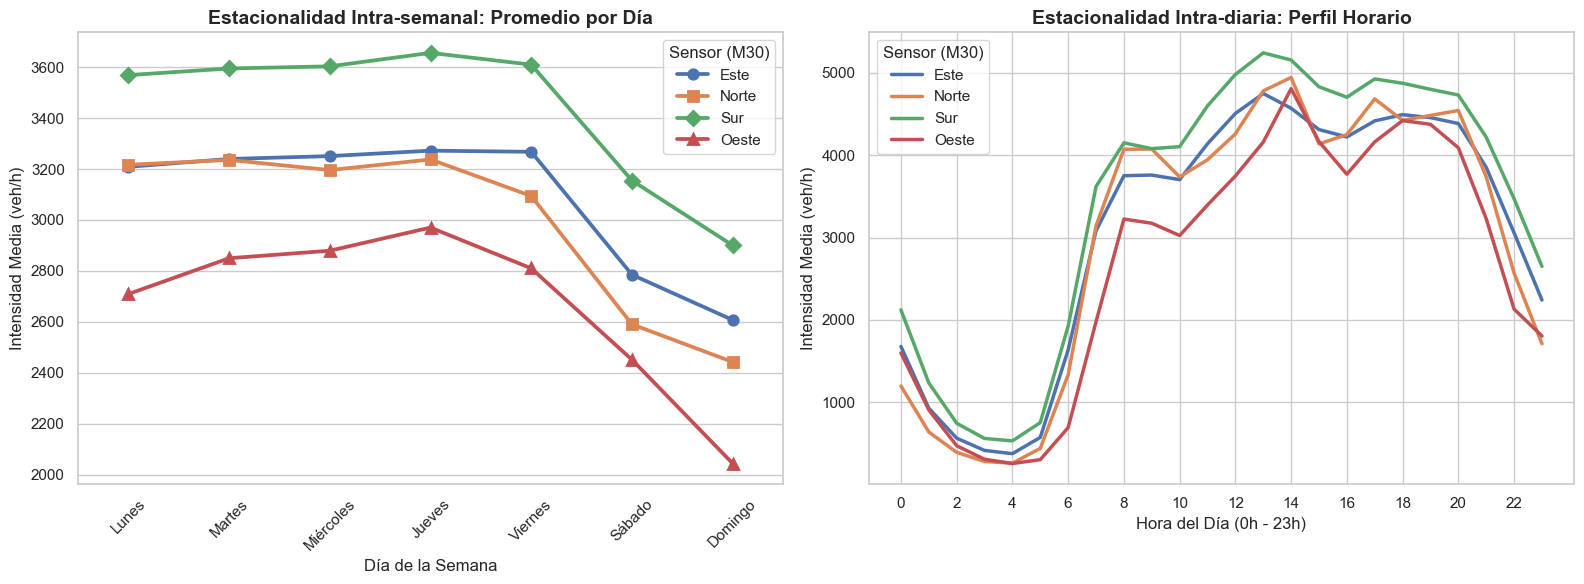

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generando visualizaciones académicas...")

# 1. Configurar el estilo del gráfico (estilo profesional/académico)
sns.set_theme(style="whitegrid", context="notebook")

# 2. Crear una figura con 2 subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO 1: Comportamiento Semanal ---
# Usamos pointplot para enfatizar el valor medio de cada día
sns.pointplot(
    data=df_oro, 
    x='dia_semana', 
    y='intensidad', 
    hue='ubicacion', 
    ax=axes[0],
    errorbar=None, # Ocultamos la varianza para ver limpia la tendencia central
    markers=['o', 's', 'D', '^']
)
axes[0].set_title('Estacionalidad Intra-semanal: Promedio por Día', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Día de la Semana', fontsize=12)
axes[0].set_ylabel('Intensidad Media (veh/h)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Sensor (M30)')

# --- GRÁFICO 2: Comportamiento Diario (Horas Punta) ---
# Usamos lineplot para ver la fluidez del paso de las horas
sns.lineplot(
    data=df_oro, 
    x='hora', 
    y='intensidad', 
    hue='ubicacion', 
    ax=axes[1],
    errorbar=None,
    linewidth=2.5
)
axes[1].set_title('Estacionalidad Intra-diaria: Perfil Horario', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hora del Día (0h - 23h)', fontsize=12)
axes[1].set_ylabel('Intensidad Media (veh/h)', fontsize=12)
axes[1].set_xticks(range(0, 24, 2)) # Mostrar ticks cada 2 horas
axes[1].legend(title='Sensor (M30)')

# Ajustar el espaciado y mostrar
plt.tight_layout()
plt.show()

In [6]:
print("Preparando el dataset definitivo para Machine Learning...")

# 1. Seleccionar solo las columnas estrictamente numéricas y necesarias
# Dependiendo se necesite se pueden exportar todas las columnas 
# Todas las columnas, cambia esta línea:
# columnas_modelo = ['id', 'ubicacion', 'fecha', 'intensidad', 'ocupacion', 'vmed', 'dia_semana', 'dia_semana_num', 'hora']

columnas_modelo = ['id', 'fecha', 'intensidad', 'ocupacion', 'vmed', 'dia_semana_num', 'hora']
df_final = df_oro[columnas_modelo].reset_index(drop=True)

# 2. Exportar el Parquet (Para los modelos de Python)
ruta_salida_parquet = "../data/processed/dataset_m30_4_sensores_final.parquet"
df_final.to_parquet(ruta_salida_parquet, index=False)
print(f"✅ Dataset Oro exportado a Parquet: {ruta_salida_parquet}")

# 3. Exportar el CSV (Para inspección manual o Excel)
ruta_salida_csv = "../data/processed/dataset_m30_4_sensores_final.csv"
df_final.to_csv(ruta_salida_csv, index=False, sep=';', encoding='utf-8')
print(f"✅ Dataset Oro exportado a CSV: {ruta_salida_csv}")

print("\n--- HITO ALCANZADO ---")
print(f"Dimensiones finales: {df_final.shape}")
print("Las fases de Data Understanding y Data Preparation (CRISP-DM) han finalizado oficialmente.")

Preparando el dataset definitivo para Machine Learning...
✅ Dataset Oro exportado a Parquet: ../data/processed/dataset_m30_4_sensores_final.parquet
✅ Dataset Oro exportado a CSV: ../data/processed/dataset_m30_4_sensores_final.csv

--- HITO ALCANZADO ---
Dimensiones finales: (74746, 7)
Las fases de Data Understanding y Data Preparation (CRISP-DM) han finalizado oficialmente.
